In [3]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

In [4]:
n = 100
X, Y = make_classification(n_samples = n, n_features=2,
                           n_redundant=0, n_informative=2, flip_y=0.05,class_sep=1.5)
X = X.astype(np.float32)
Y = Y.astype(np.int32)

split = [ 70*n//100 ]
train_x, test_x = np.split(X, split)
train_labels, test_labels = np.split(Y, split)

In [ ]:
# Plot the dataset med og uten beslutningsgrense
def plot_dataset(features, labels, W=None, b=None):
    # prepare the plot
    fig, ax = plt.subplots(1, 1)
    ax.set_xlabel('$x_i[0]$ -- (feature 1)')
    ax.set_ylabel('$x_i[1]$ -- (feature 2)')
    colors = ['r' if l else 'b' for l in labels]
    ax.scatter(features[:, 0], features[:, 1], marker='o', c=colors, s=100, alpha = 0.5)
    if W is not None:
        min_x = min(features[:,0])
        max_x = max(features[:,1])
        min_y = min(features[:,1])*(1-.1)
        max_y = max(features[:,1])*(1+.1)
        cx = np.array([min_x,max_x],dtype=np.float32)
        cy = (0.5-W[0]*cx-b)/W[1]
        ax.plot(cx,cy,'g')
        ax.set_ylim(min_y,max_y)
    fig.show()

plot_dataset(train_x, train_labels)

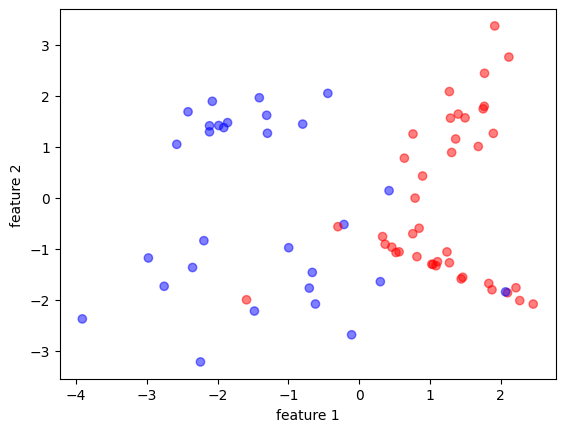

In [6]:
# Enkelt plot av treningsdataene med fargekodede klasser
plt.scatter(train_x[:, 0], train_x[:, 1], c=train_labels, cmap='bwr', alpha=0.5)
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.show()

In [7]:
# Gjør om så data kan brukes i TensorFlow
train_x_norm = (train_x-np.min(train_x,axis=0)) / (np.max(train_x,axis=0)-np.min(train_x,axis=0))
test_x_norm = (test_x-np.min(train_x,axis=0)) / (np.max(train_x,axis=0)-np.min(train_x,axis=0))

In [ ]:
model = keras.models.Sequential()
model.add(keras.Input(shape=(2,)))
model.add(keras.layers.Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.2),loss='binary_crossentropy',metrics=['acc'])

In [15]:
model.fit(x=train_x_norm,y=train_labels,validation_data=(test_x_norm,test_labels),epochs=10,batch_size=1)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.5429 - loss: 0.6807 - val_acc: 0.3333 - val_loss: 0.6852
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7143 - loss: 0.5827 - val_acc: 0.3333 - val_loss: 0.7214
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7714 - loss: 0.5230 - val_acc: 0.6667 - val_loss: 0.5903
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8143 - loss: 0.4815 - val_acc: 0.8333 - val_loss: 0.4698
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8286 - loss: 0.4488 - val_acc: 0.8667 - val_loss: 0.4374
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8571 - loss: 0.4213 - val_acc: 0.8000 - val_loss: 0.4533
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8571 - loss: 0.3978 - val_acc: 0.9333 - val_loss: 0.3504
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8714 - loss: 0.3858 - val_acc: 0.9000 - val_loss: 0.3769
Epoch 9/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9000 - loss: 

C:\Users\jsand\AppData\Local\Temp\ipykernel_7228\3155907829.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


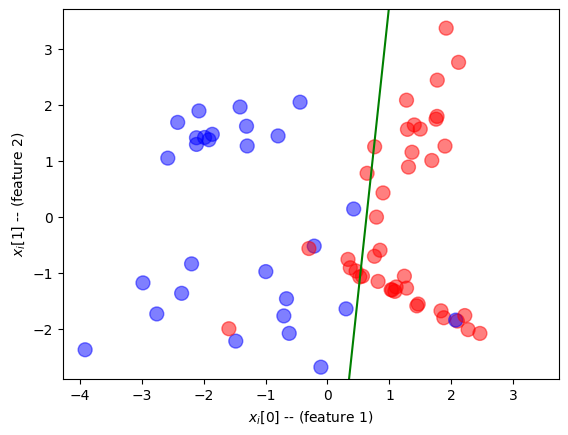

In [16]:
plot_dataset(train_x,train_labels,model.layers[0].weights[0],model.layers[0].weights[1])

In [19]:
model = keras.models.Sequential([
    keras.layers.Dense(1,input_shape=(2,),activation='sigmoid')])
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.05),loss='binary_crossentropy',metrics=['acc'])
hist = model.fit(x=train_x_norm,y=train_labels,validation_data=(test_x_norm,test_labels),epochs=10,batch_size=1)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.5857 - loss: 0.6588 - val_acc: 0.3000 - val_loss: 0.7402
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6143 - loss: 0.6306 - val_acc: 0.3000 - val_loss: 0.7585
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6000 - loss: 0.6118 - val_acc: 0.3000 - val_loss: 0.7341
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6429 - loss: 0.5928 - val_acc: 0.3333 - val_loss: 0.6868
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6857 - loss: 0.5739 - val_acc: 0.3333 - val_loss: 0.6647
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6714 - loss: 0.5562 - val_acc: 0.6000 - val_loss: 0.6189
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7571 - loss: 0.5418 - val_acc: 0.6667 - val_loss: 0.6088
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7714 - loss: 0.5266 - val_acc: 0.7333 - val_loss: 0.5822
Epoch 9/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8286 - loss: 

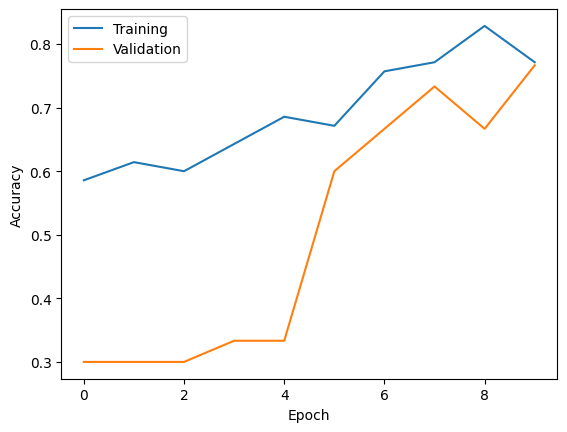

In [21]:
plt.plot(hist.history['acc'])
plt.plot(hist.history['val_acc'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training', 'Validation'])
plt.show()

In [25]:
model = keras.models.Sequential([
    keras.layers.Dense(5,input_shape=(2,),activation='relu'),
    keras.layers.Dense(2,activation='softmax')
])
model.compile(
    optimizer=keras.optimizers.Adam(0.01),
    loss='categorical_crossentropy',
    metrics=['acc']
)

# Two ways to convert to one-hot encoding
train_labels_onehot = keras.utils.to_categorical(train_labels)
test_labels_onehot = np.eye(2)[test_labels]

hist = model.fit(x=train_x_norm,y=train_labels_onehot,
                 validation_data=[test_x_norm,test_labels_onehot],batch_size=1,epochs=10)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.7429 - loss: 0.6221 - val_acc: 0.5333 - val_loss: 0.6726
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7857 - loss: 0.5351 - val_acc: 0.8000 - val_loss: 0.5360
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8571 - loss: 0.4628 - val_acc: 0.8000 - val_loss: 0.4519
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8571 - loss: 0.4085 - val_acc: 0.9333 - val_loss: 0.3550
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8714 - loss: 0.3885 - val_acc: 0.8333 - val_loss: 0.3595
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8714 - loss: 0.3637 - val_acc: 0.9000 - val_loss: 0.2858
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8714 - loss: 0.3278 - val_acc: 0.9000 - val_loss: 0.3156
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8857 - loss: 0.3173 - val_acc: 0.9000 - val_loss: 0.2553
Epoch 9/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8857 - loss: 

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['acc']
)
model.fit(x=train_x_norm,y=train_labels,validation_data=[test_x_norm,test_labels],batch_size=1,epochs=10)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9000 - loss: 0.2831 - val_acc: 0.9333 - val_loss: 0.1654
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9143 - loss: 0.2680 - val_acc: 0.9000 - val_loss: 0.1936
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9000 - loss: 0.2654 - val_acc: 0.9333 - val_loss: 0.1837
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9000 - loss: 0.2647 - val_acc: 0.9000 - val_loss: 0.1873
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9000 - loss: 0.2656 - val_acc: 0.9333 - val_loss: 0.1336
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9143 - loss: 0.2541 - val_acc: 0.9000 - val_loss: 0.1894
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9143 - loss: 0.2644 - val_acc: 0.9333 - val_loss: 0.1530
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9143 - loss: 0.2589 - val_acc: 0.9333 - val_loss: 0.1609
Epoch 9/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9000 - loss: 

## 1. Data: generering, splitting, normalisering

**`make_classification`**
```python
X, Y = make_classification(n_samples=n, n_features=2, n_redundant=0,
                            n_informative=2, flip_y=0.05, class_sep=1.5)
```
- Ingen hard øvre grense på `n_samples` — begrenses kun av RAM og ytelse.
- Én reell strukturell begrensning: `n_classes * n_clusters_per_class <= 2**n_informative`.

**Train/test-splitting**
```python
split = [70*n//100]
train_x, test_x = np.split(X, split)
```
Dette gir en korrekt 70/30-splitt (indeks 0–69 vs. 70–99). Merk: dataene bør sjekkes for klassebalanse (`np.bincount`) eller stokkes, siden `np.split` ikke shuffler — `train_test_split` fra scikit-learn gjør dette automatisk og kan stratifisere.

**Normalisering**
```python
train_x_norm = (train_x - np.min(train_x, axis=0)) / (np.max(train_x, axis=0) - np.min(train_x, axis=0))
test_x_norm = (test_x - np.min(train_x, axis=0)) / (np.max(train_x, axis=0) - np.min(train_x, axis=0))
```
Min/maks beregnes kun på treningsdata, og brukes til å skalere begge sett — simulerer at man i praksis ikke kjenner fremtidige data på forhånd.

**Enkel plotting** (som alternativ til den mer kompliserte `plot_dataset`-funksjonen med decision boundary):
```python
plt.scatter(train_x[:, 0], train_x[:, 1], c=train_labels, cmap='bwr', alpha=0.5)
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.show()
```

---

## 2. Bygge en modell (Sequential API)

**Standard oppskrift (bygg → kompiler → tren → evaluer):**
```python
model = keras.models.Sequential()
model.add(keras.Input(shape=(2,)))
model.add(keras.layers.Dense(1, activation='sigmoid'))
model.summary()

model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.2),
              loss='binary_crossentropy', metrics=['acc'])

model.fit(x=train_x_norm, y=train_labels,
          validation_data=(test_x_norm, test_labels),
          epochs=10, batch_size=1)
```

**To måter å skrive samme modell på:**
```python
# Variant A: add() steg for steg
model = keras.models.Sequential()
model.add(keras.Input(shape=(2,)))
model.add(keras.layers.Dense(1, activation='sigmoid'))

# Variant B: liste rett i konstruktøren
model = keras.models.Sequential([
    keras.layers.Dense(1, input_shape=(2,), activation='sigmoid')
])
```
Disse er arkitektonisk identiske. **Viktig fallgruve:** å skrive `Sequential([...])` og deretter `.add(...)` med samme lag-spesifikasjon legger til et **ekstra** lag ved uhell (dobling), ikke en duplisering av det samme laget.

**Å skrive `model = keras.models.Sequential([...])` på nytt** overskriver variabelen `model` fullstendig — den gamle (trente) modellen forsvinner. Dette er riktig når man bevisst vil starte med friske, tilfeldige vekter (f.eks. for å teste en annen learning rate), men feil hvis man trodde man bygget videre på en eksisterende modell.

**Hva `model.summary()` viser:** antall parametere (vekter + bias) per lag. Et Dense-lag med `n` input og `m` neuroner har `n*m + m` parametere (vektene + én bias per neuron). Aktiveringslag har alltid 0 parametere — de gjør en fast matematisk transformasjon, ikke læring.

**Hva som skjer "i praksis" i ett Dense+sigmoid-lag:**
```
z = w1*x1 + w2*x2 + b        # vektet sum
output = 1 / (1 + e^(-z))    # sigmoid, gir sannsynlighet mellom 0 og 1
```
Trening (`model.fit`) justerer `w1`, `w2`, `b` gradvis via optimizeren (SGD/Adam) for å minimere loss. Med kun 3 parametere kan modellen bare tegne en **rett** beslutningsgrense — tilstrekkelig for lineært separerbare data som i `make_classification` med `class_sep=1.5`.

---

## 3. Vanlig feil: posisjonelle argumenter i `compile()`

**Feilkoden:**
```python
model.compile(keras.optimizers.Adam(0.01), 'categorical_crossentropy', ['acc'])
```
**Feilmelding:**
```
ValueError: dtype='string' is not a valid dtype for Keras type promotion.
```

**Årsak:** I Keras 3 er signaturen `compile(optimizer, loss, loss_weights, metrics, ...)`. Med posisjonelle argumenter havner `['acc']` i `loss_weights`-posisjonen i stedet for `metrics`. Feilen oppstår i `fit()`, ikke i `compile()`, siden loss-vektingen først brukes under trening.

**Løsning — bruk alltid keyword arguments:**
```python
model.compile(optimizer=keras.optimizers.Adam(0.01),
              loss='categorical_crossentropy',
              metrics=['acc'])
```
Generell lærdom: eldre tutorials skrevet for Keras 2 kan bruke posisjonelle argumenter som ikke lenger er trygge i Keras 3. Keyword arguments er mer robuste mot API-endringer.

---

## 4. Loss-funksjoner og label-format

| Klassifiseringstype | Label-format | Aktivering (siste lag) | Loss |
|---|---|---|---|
| Binær | Sannsynlighet for 1 klasse | sigmoid | `binary_crossentropy` |
| Binær | One-hot (2 outputs) | softmax | `categorical_crossentropy` |
| Multiklasse | One-hot | softmax | `categorical_crossentropy` |
| Multiklasse | Klassenummer (heltall) | softmax | `sparse_categorical_crossentropy` |
| Multilabel | One-hot | sigmoid | `binary_crossentropy` |

**Eksempel one-hot + categorical_crossentropy:**
```python
train_labels_onehot = keras.utils.to_categorical(train_labels)  # eller np.eye(2)[test_labels]
model.compile(optimizer=..., loss='categorical_crossentropy', metrics=['acc'])
model.fit(x=train_x_norm, y=train_labels_onehot, ...)
```

**Eksempel sparse categorical (unngår one-hot helt):**
```python
model.compile(optimizer=..., loss='sparse_categorical_crossentropy', metrics=['acc'])
model.fit(x=train_x_norm, y=train_labels, ...)  # rå heltall, ikke one-hot
```
Matematisk identisk resultat som `categorical_crossentropy` — forskjellen er bare input-format. `sparse_categorical_crossentropy` sparer kode og minne, spesielt relevant med mange klasser.

---